
================ METRICHE =================

                     metric       value
           Final Equity (€) 1163.625731
           Total Return (€)  163.625731
           Total Return (%)   16.362573
      Avg PnL per Trade (€)    0.187731
   Avg Return per Trade (%)    3.847175
               Win Rate (%)   60.570071
  Mean Return per Trade (%)    3.847175
Median Return per Trade (%)    5.633881
   Std Return per Trade (%)   26.229074
           Number of Trades  842.000000

=========== STATISTICHE POSIZIONI GIORNALIERE ===========

Giorni con 10 posizioni aperte: 96
Giorni con meno di 10 posizioni: 2745
Giorni senza alcuna posizione: 781

Tabella riepilogo:
             Category  Days
         10 positions    96
1–{2*N - 1} positions  2745
          0 positions   781


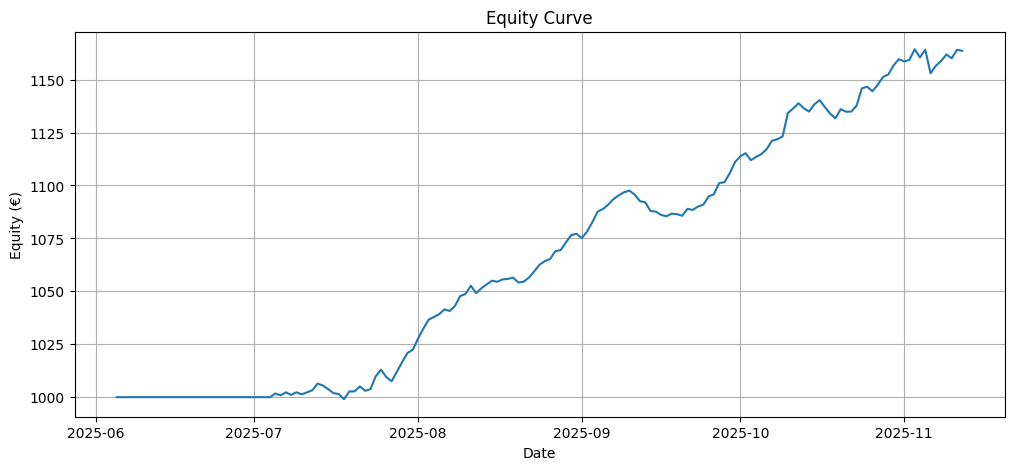

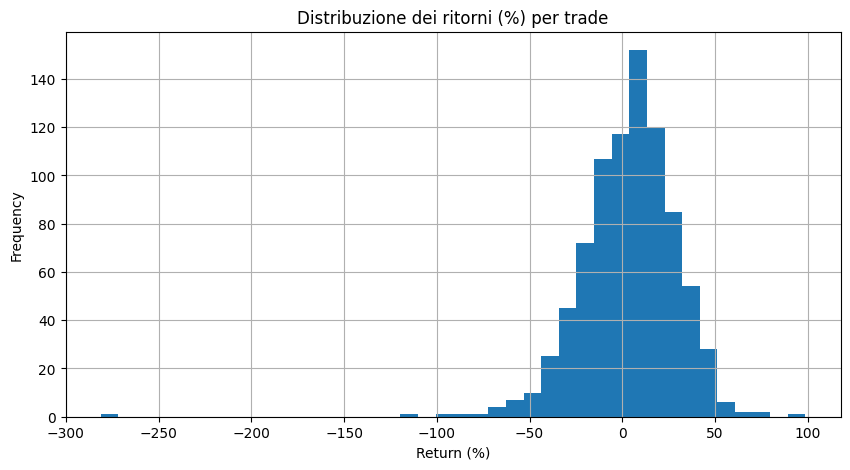

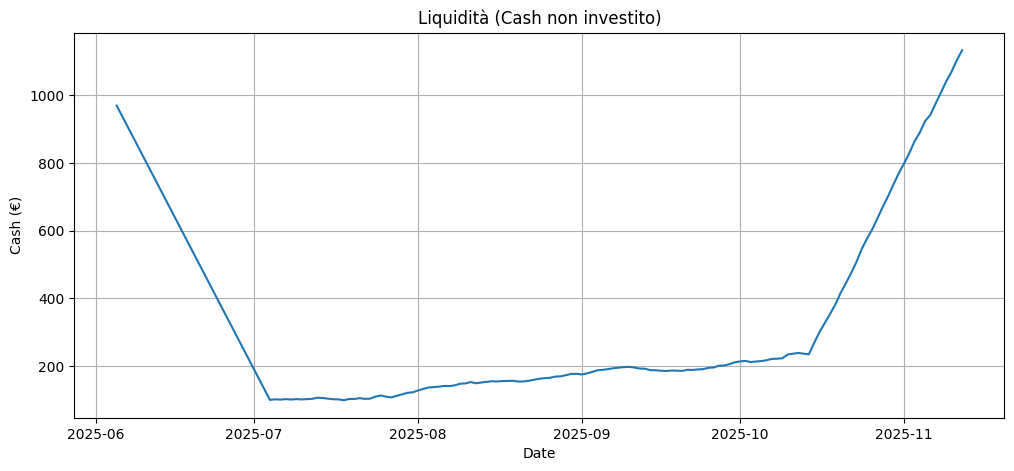


File CSV salvato correttamente: trades_export.csv


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
initial_capital = 1000
daily_budget = 30   # totale da investire ogni giorno
N = 5               # numero di top e bottom da considerare ogni giorno

# === LOAD DATA ===
ranks = pd.read_csv("ranks.csv", parse_dates=["release_date"])
prices = pd.read_csv("all_perps_18h_closing_prices.csv", parse_dates=["time"])

# Preprocessing
prices["date"] = prices["time"].dt.date
ranks["date"] = ranks["release_date"].dt.date

ranks = ranks.sort_values("date")
prices = prices.sort_values("date")

trades = []
equity = initial_capital
equity_curve = []
cash_curve = []

capital_invested = 0   # capitale impegnato in posizioni aperte

open_positions = []  # lista di posizioni ancora aperte

unique_days = sorted(ranks["date"].unique())


# ============================================================
# ===================== MAIN LOOP =============================
# ============================================================

for day in unique_days:

    # ---- 1. Chiudi le posizioni con close_date == day ----
    positions_to_close = [p for p in open_positions if p["close_date"] == day]

    day_pnl = 0
    for pos in positions_to_close:
        capital_invested -= pos["position_size"]  # svincola capitale reale investito
        day_pnl += pos["pnl"]
        open_positions.remove(pos)

    # ---- 2. Costruisci le posizioni candidate del giorno ----
    day_df = ranks[ranks["date"] == day]

    topN = day_df.nlargest(N, "pred_30d")
    botN = day_df.nsmallest(N, "pred_30d")

    candidates = []

    # LONG
    for _, row in topN.iterrows():
        token = row["id"]
        open_date = row["date"]
        close_date = open_date + pd.Timedelta(days=30)

        open_row = prices[(prices["date"] == open_date) & (prices["perp"] == token)]
        close_row = prices[(prices["date"] == close_date) & (prices["perp"] == token)]

        if open_row.empty or close_row.empty:
            continue

        candidates.append({
            "token": token,
            "side": "LONG",
            "open_price": open_row["close"].iloc[0],
            "close_price": close_row["close"].iloc[0],
            "open_date": open_date,
            "close_date": close_date
        })

    # SHORT
    for _, row in botN.iterrows():
        token = row["id"]
        open_date = row["date"]
        close_date = open_date + pd.Timedelta(days=30)

        open_row = prices[(prices["date"] == open_date) & (prices["perp"] == token)]
        close_row = prices[(prices["date"] == close_date) & (prices["perp"] == token)]

        if open_row.empty or close_row.empty:
            continue

        candidates.append({
            "token": token,
            "side": "SHORT",
            "open_price": open_row["close"].iloc[0],
            "close_price": close_row["close"].iloc[0],
            "open_date": open_date,
            "close_date": close_date
        })

    # ---- 3. Redistribuzione del budget (SEMPRE 30€ INVESTITI) ----
    n_pos = len(candidates)
    if n_pos > 0:
        position_size = daily_budget / n_pos
    else:
        position_size = 0  # nessuna posizione oggi

    # salva quante posizioni sono state aperte oggi
    if "daily_positions" not in globals():
        daily_positions = []

    daily_positions.append({"date": day, "positions": n_pos})


    # ---- 4. Apri effettivamente le posizioni ----
    for pos in candidates:

        op = pos["open_price"]
        cp = pos["close_price"]

        # === PARAMETRI REALISTICI ===
        fee_rate = 0.00045          # 0.045% per lato (Hyperliquid taker)
        spread_bps = 0.0002         # 0.02% per lato
        slippage_bps = 0.0005       # 0.05% per lato

        # Spread + slippage totale
        total_impairment = spread_bps + slippage_bps

        # === Aggiustamento prezzi per spread/slippage ===
        if pos["side"] == "LONG":
            effective_op = op * (1 + total_impairment)
            effective_cp = cp * (1 - total_impairment)
            ret = (effective_cp - effective_op) / effective_op
        else:  # SHORT
            effective_op = op * (1 - total_impairment)
            effective_cp = cp * (1 + total_impairment)
            ret = (effective_op - effective_cp) / effective_op

        # === Fees ===
        notional = position_size     # leva 1x
        fees = notional * fee_rate * 2  # open + close

        # === PNL netto ===
        pnl = position_size * ret - fees

        capital_invested += position_size

        open_positions.append({
            "close_date": pos["close_date"],
            "position_size": position_size,
            "pnl": pnl
        })

        trades.append({
            "token": pos["token"],
            "side": pos["side"],
            "open_date": pos["open_date"],
            "close_date": pos["close_date"],
            "open_price": op,
            "close_price": cp,
            "effective_open": effective_op,
            "effective_close": effective_cp,
            "position_size": position_size,
            "return": ret,
            "fees": fees,
            "pnl_eur": pnl
        })


    # ---- 5. Aggiorna equity ----
    equity += day_pnl

    # ---- 6. Calcola liquidità ----
    cash = equity - capital_invested

    equity_curve.append({"date": day, "equity": equity})
    cash_curve.append({"date": day, "cash": cash})


# ============================================================
# ===================== OUTPUT ================================
# ============================================================

equity_df = pd.DataFrame(equity_curve)
cash_df = pd.DataFrame(cash_curve)

# ============================================================
# ===================== METRICHE ===============================
# ============================================================

trades_df = pd.DataFrame(trades)

# Ritorno totale in €
total_return_eur = equity - initial_capital

# Ritorno percentuale totale
total_return_pct = (equity / initial_capital - 1) * 100

# Ritorno medio per trade (in €)
avg_pnl_trade = trades_df["pnl_eur"].mean()

# Ritorno percentuale medio per trade
avg_return_pct_trade = trades_df["return"].mean() * 100

# Win rate
win_rate = (trades_df["pnl_eur"] > 0).mean() * 100

# Statistiche sulla distribuzione dei ritorni trade-by-trade
mean_ret = trades_df["return"].mean() * 100
median_ret = trades_df["return"].median() * 100
std_ret = trades_df["return"].std() * 100

# ============================================================
# ============= PRINT METRICHE IN TABELLA =====================
# ============================================================

metrics = pd.DataFrame({
    "metric": [
        "Final Equity (€)",
        "Total Return (€)",
        "Total Return (%)",
        "Avg PnL per Trade (€)",
        "Avg Return per Trade (%)",
        "Win Rate (%)",
        "Mean Return per Trade (%)",
        "Median Return per Trade (%)",
        "Std Return per Trade (%)",
        "Number of Trades"
    ],
    "value": [
        equity,
        total_return_eur,
        total_return_pct,
        avg_pnl_trade,
        avg_return_pct_trade,
        win_rate,
        mean_ret,
        median_ret,
        std_ret,
        len(trades_df)
    ]
})

print("\n================ METRICHE =================\n")
print(metrics.to_string(index=False))


# ============================================================
# ====== STATISTICHE SUL NUMERO DI POSIZIONI GIORNALIERE =====
# ============================================================

daily_pos_df = pd.DataFrame(daily_positions)

days_with_10 = (daily_pos_df["positions"] == 2*N).sum()
days_with_less = ((daily_pos_df["positions"] > 0) & (daily_pos_df["positions"] < 2*N)).sum()
days_with_zero = (daily_pos_df["positions"] == 0).sum()

print("\n=========== STATISTICHE POSIZIONI GIORNALIERE ===========\n")
print(f"Giorni con {2*N} posizioni aperte: {days_with_10}")
print(f"Giorni con meno di {2*N} posizioni: {days_with_less}")
print(f"Giorni senza alcuna posizione: {days_with_zero}")

# Tabella riepilogo
summary_pos = pd.DataFrame({
    "Category": [f"{2*N} positions", "1–{2*N - 1} positions", "0 positions"],
    "Days": [days_with_10, days_with_less, days_with_zero]
})

print("\nTabella riepilogo:")
print(summary_pos.to_string(index=False))


# ============================================================
# ==================== GRAFICO EQUITY =========================
# ============================================================

plt.figure(figsize=(12,5))
plt.plot(equity_df["date"], equity_df["equity"])
plt.title("Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity (€)")
plt.grid()
plt.show()

# ============================================================
# =========== DISTRIBUZIONE DEI RITORNI DEI TRADE =============
# ============================================================

plt.figure(figsize=(10,5))
plt.hist(trades_df["return"] * 100, bins=40)
plt.title("Distribuzione dei ritorni (%) per trade")
plt.xlabel("Return (%)")
plt.ylabel("Frequency")
plt.grid()
plt.show()


# === Plot della liquidità ===
plt.figure(figsize=(12,5))
plt.plot(cash_df["date"], cash_df["cash"])
plt.title("Liquidità (Cash non investito)")
plt.xlabel("Date")
plt.ylabel("Cash (€)")
plt.grid()
plt.show()

# ============================================================
# ===================== EXPORT TRADES =========================
# ============================================================

output_filename = "trades_export.csv"
trades_df.to_csv(output_filename, index=False)

print(f"\nFile CSV salvato correttamente: {output_filename}")



In [32]:
import pandas as pd

# === LOAD TRADES ===
trades_df = pd.read_csv("trades_export.csv", parse_dates=["open_date", "close_date"])

# ================================
# 1. Token con più trade totali
# ================================

trade_counts = trades_df["token"].value_counts()
print("\n===== TOKEN CON PIÙ TRADE TOTALI =====")
print(trade_counts.head(20))

# ================================
# 2. Token con più LONG
# ================================

long_counts = trades_df[trades_df["side"] == "LONG"]["token"].value_counts()
print("\n===== TOKEN CON PIÙ LONG =====")
print(long_counts.head(20))

# ================================
# 3. Token con più SHORT
# ================================

short_counts = trades_df[trades_df["side"] == "SHORT"]["token"].value_counts()
print("\n===== TOKEN CON PIÙ SHORT =====")
print(short_counts.head(20))

# ================================
# 4. Profitto totale per token
# ================================

pnl_total = trades_df.groupby("token")["pnl_eur"].sum()
pnl_long = trades_df[trades_df["side"] == "LONG"].groupby("token")["pnl_eur"].sum()
pnl_short = trades_df[trades_df["side"] == "SHORT"].groupby("token")["pnl_eur"].sum()

# ================================
# 5. Tabella riassuntiva completa
# ================================

summary = pd.DataFrame({
    "total_trades": trade_counts,
    "long_trades": long_counts,
    "short_trades": short_counts,
    "pnl_total": pnl_total,
    "pnl_long": pnl_long,
    "pnl_short": pnl_short,
}).fillna(0)

# === ORDINAMENTO per numero totale di trade (come richiesto) ===
summary = summary.sort_values("total_trades", ascending=False)

print("\n===== TABELLA COMPLETA: LONG + SHORT + TOTAL + PROFITS (ordinata per numero di trade) =====")
print(summary.head(30))



===== TOKEN CON PIÙ TRADE TOTALI =====
token
BNB           43
BTC           32
SOL           28
LAUNCHCOIN    23
OM            22
MAV           21
MOVE          20
ATOM          19
ADA           19
PROVE         18
AVAX          18
RENDER        18
VINE          17
DOGE          15
SAND          15
ONDO          14
MEME          13
LINK          13
AIXBT         13
APT           13
Name: count, dtype: int64

===== TOKEN CON PIÙ LONG =====
token
BNB       43
BTC       32
SOL       28
ATOM      19
ADA       19
AVAX      18
RENDER    18
SAND      15
DOGE      15
ONDO      14
LINK      13
SUI       12
SOPH      11
APT       11
TRX       10
XRP       10
MNT        9
ALGO       9
JUP        7
NEAR       7
Name: count, dtype: int64

===== TOKEN CON PIÙ SHORT =====
token
LAUNCHCOIN    23
OM            22
MAV           21
MOVE          19
PROVE         18
VINE          17
MEME          13
AIXBT         13
HYPER         12
AVNT          11
FARTCOIN      11
KAITO         11
TST           10
VVV 